# Check data satellite

In [32]:
import boto3
import subprocess

# Récupère les credentials du profil edth2026 directement
session = boto3.Session(profile_name="edth2026")
s3 = session.client("s3", region_name="eu-west-3")

# Liste le bucket
response = s3.list_objects_v2(Bucket="edth2026-baltic", Delimiter="/")
for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])

ais/
cameras/
geo/
kaggle/
optical/
reference/
samples/
sar/


In [33]:
# Explore le dossier SAR
response = s3.list_objects_v2(Bucket="edth2026-baltic", Prefix="sar/")

for obj in response.get("Contents", []):
    print(obj["Key"])

sar/capella/.keep
sar/sentinel1/.keep
sar/sentinel1/INC-2022-09-26_sar.jpg
sar/sentinel1/INC-2023-10-08_sar.jpg
sar/sentinel1/INC-2024-11-17_sar.jpg
sar/sentinel1/INC-2024-11-18_sar.jpg
sar/sentinel1/INC-2024-12-25_sar.jpg
sar/sentinel1/INC-2025-01-26_sar.jpg
sar/sentinel1/INC-2025-02-21_sar.jpg
sar/sentinel1/INC-2025-12-31_sar.jpg
sar/sentinel1/INC-2026-01-02_sar.jpg
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-17T043415_DESCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-17T154903_ASCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-22T044207_DESCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-22T044232_DESCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-22T155703_ASCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-29T043415_DESCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2024-12-29T154902_ASCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2025-01-03T044206_DESCENDING.tif
sar/sentinel1/geotiff/INC-2024-12-25_2025-01-03T044231_DESCENDING.tif
sa

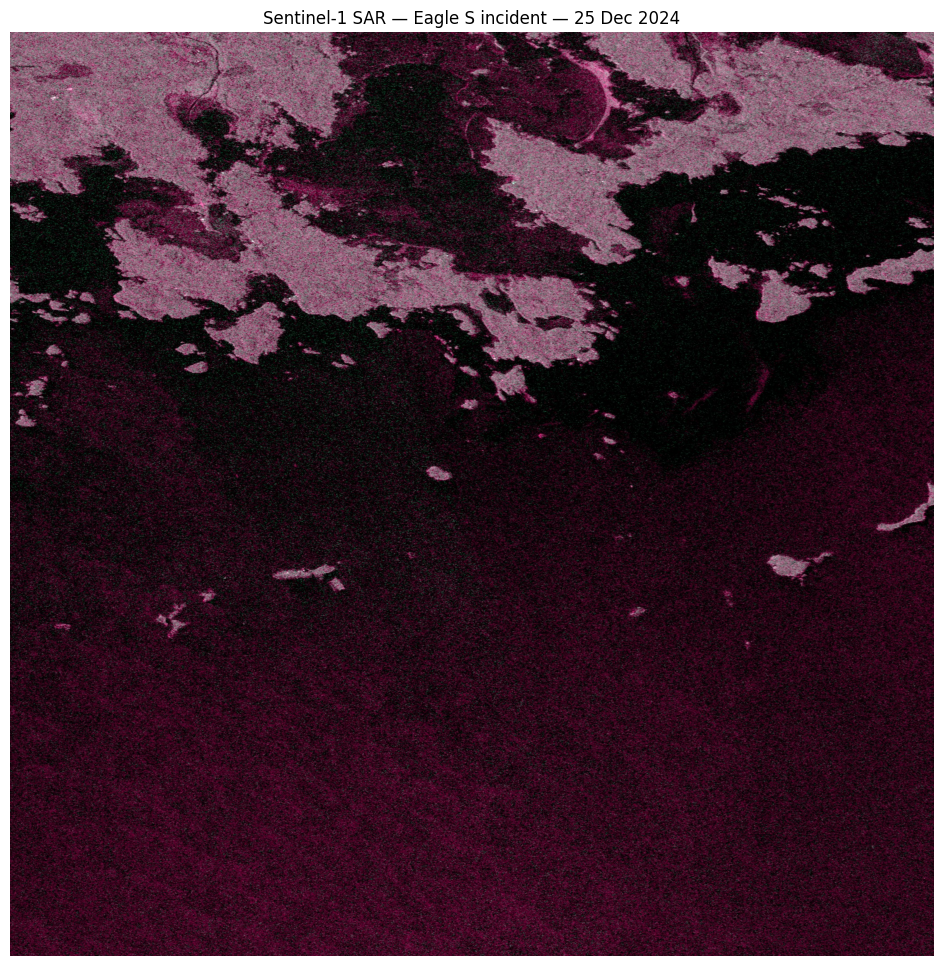

Image shape: (2048, 2048, 3)


In [34]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
from io import BytesIO

# Télécharge l'image Eagle S (25 dec 2024)
obj = s3.get_object(Bucket="edth2026-baltic", Key="sar/sentinel1/INC-2024-12-25_sar.jpg")
img_data = obj["Body"].read()

# Affiche
img = np.array(Image.open(BytesIO(img_data)))
plt.figure(figsize=(12, 12))
plt.imshow(img, cmap="gray")
plt.title("Sentinel-1 SAR — Eagle S incident — 25 Dec 2024")
plt.axis("off")
plt.show()

print(f"Image shape: {img.shape}")

In [35]:
import numpy as np

print(f"Shape: {img.shape}")
print(f"Dtype: {img.dtype}")
print(f"Min/Max valeurs: {img.min()} / {img.max()}")
print(f"Dimensions: {img.shape[1]}px largeur x {img.shape[0]}px hauteur")

# Est-ce que c'est en niveaux de gris ou RGB ?
if len(img.shape) == 3:
    print(f"Canaux: {img.shape[2]} (RGB)")
else:
    print("Niveaux de gris")

Shape: (2048, 2048, 3)
Dtype: uint8
Min/Max valeurs: 0 / 255
Dimensions: 2048px largeur x 2048px hauteur
Canaux: 3 (RGB)


In [36]:
# Liste les datasets Kaggle SAR disponibles
response = s3.list_objects_v2(Bucket="edth2026-baltic", Prefix="kaggle/", Delimiter="/")

for prefix in response.get("CommonPrefixes", []):
    print(prefix["Prefix"])

kaggle/2022-ukraine-russian-war/
kaggle/afo-aerial-dataset-of-floating-objects/
kaggle/ais-dataset/
kaggle/daily-port-activity-data-and-trade-estimates/
kaggle/high-resolution-sar-images-dataset-hrsid/
kaggle/ls-ssdd-v1-0/
kaggle/sarscope-unveiling-the-maritime-landscape/
kaggle/sds-dataset/
kaggle/ship-ports/
kaggle/ships-in-satellite-imagery/


=== HRSID ===
Total fichiers : 1000
Images PNG : 997
Autres fichiers : ['kaggle/high-resolution-sar-images-dataset-hrsid/annotations/test2017.json', 'kaggle/high-resolution-sar-images-dataset-hrsid/annotations/train2017.json', 'kaggle/high-resolution-sar-images-dataset-hrsid/annotations/train_test2017.json']

Image sample : P0001_1200_2000_8400_9200.png
Shape : (800, 800, 3)
Dtype : float32
Min/Max : 0.00 / 1.00


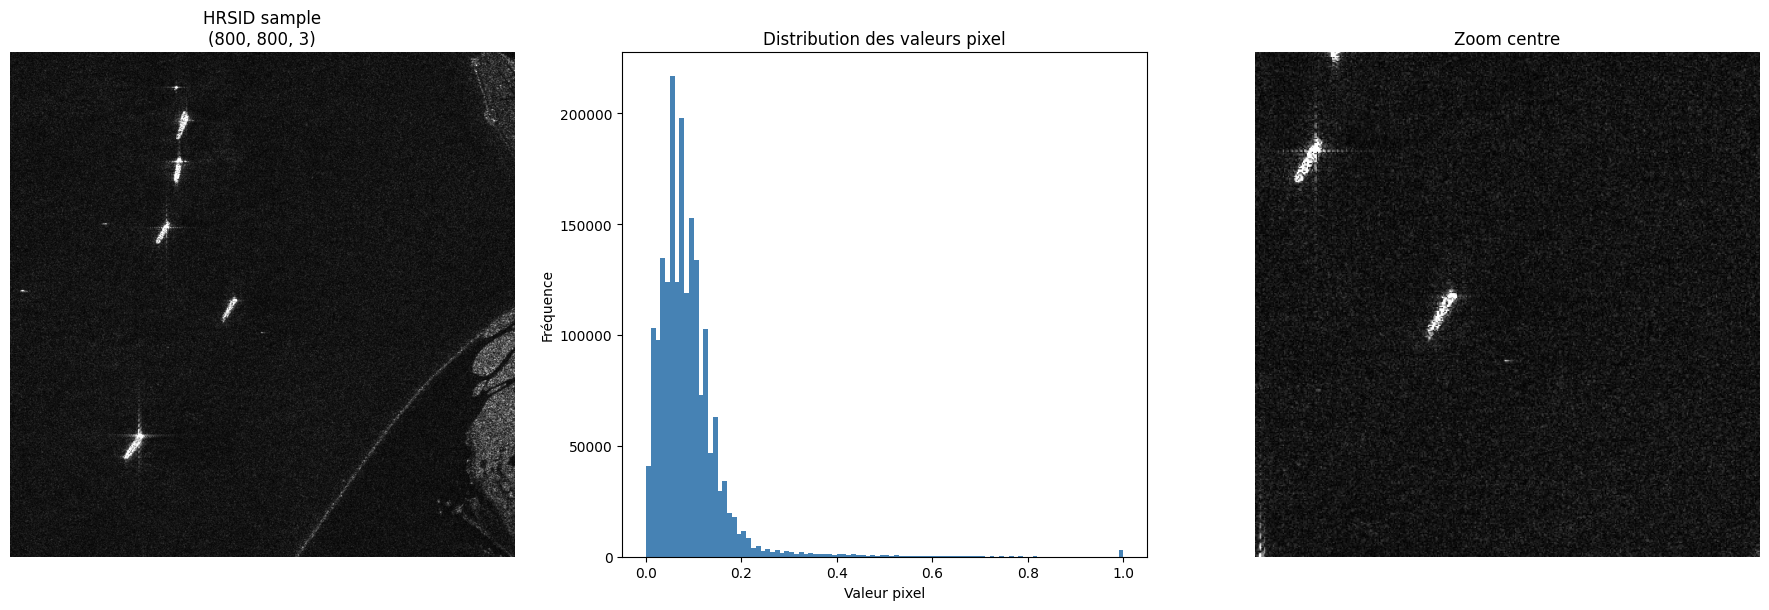


=== SARScope ===
SARscope/README.roboflow.txt
SARscope/test/000003_jpg.rf.d35f1b3e7a2f971d5edb6bd95bdb0af4.jpg
SARscope/test/000047_jpg.rf.a7c5a75819459815e026bd5f7c0c5d3d.jpg
SARscope/test/000059_jpg.rf.e7369a146592d0d45241a640ac951d5c.jpg
SARscope/test/000062_jpg.rf.74c3c4bcb7a59fb971a4bbe573235055.jpg
SARscope/test/000069_jpg.rf.34afecb18bccfc3ce078330ec0d18094.jpg
SARscope/test/000086_jpg.rf.bbc50f90494434e8ea43df96263ff54a.jpg
SARscope/test/000096_jpg.rf.2ceab787373bba737023b8fced5b2cb0.jpg
SARscope/test/000097_jpg.rf.7ee59769af8798229e3743973e1f6c53.jpg
SARscope/test/000102_jpg.rf.84505608b8aebe9d823612f8ddae5605.jpg
SARscope/test/000109_jpg.rf.8f6f3b337d10731fc03aa70cb1a0156c.jpg
SARscope/test/000113_jpg.rf.39f9bbcc4447dd3d8b6ce6f345620c7e.jpg
SARscope/test/000121_jpg.rf.887057cf040ac378dfdcec9e4d484a5e.jpg
SARscope/test/000127_jpg.rf.c39ba2430b70214e04e1834d9a3bd75a.jpg
SARscope/test/000129_jpg.rf.44f90ab89738208a322012f7cc687f1a.jpg
SARscope/test/000140_jpg.rf.f6ee1977e862b22

In [37]:
import json
from io import BytesIO

# ── 1. Structure HRSID ────────────────────────────────────────────────────────
response = s3.list_objects_v2(
    Bucket="edth2026-baltic",
    Prefix="kaggle/high-resolution-sar-images-dataset-hrsid/",
)
all_keys = [obj["Key"] for obj in response.get("Contents", [])]
non_images = [k for k in all_keys if not k.endswith(".png")]
png_files = [k for k in all_keys if k.endswith(".png")]

print(f"=== HRSID ===")
print(f"Total fichiers : {len(all_keys)}")
print(f"Images PNG : {len(png_files)}")
print(f"Autres fichiers : {non_images}")

# ── 2. Charge une image HRSID pour voir ──────────────────────────────────────
sample_key = png_files[10]  # prend une image au hasard
obj = s3.get_object(Bucket="edth2026-baltic", Key=sample_key)
sample_img = mpimg.imread(BytesIO(obj["Body"].read()))

print(f"\nImage sample : {sample_key.split('/')[-1]}")
print(f"Shape : {sample_img.shape}")
print(f"Dtype : {sample_img.dtype}")
print(f"Min/Max : {sample_img.min():.2f} / {sample_img.max():.2f}")

# ── 3. Affiche l'image ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Image brute
axes[0].imshow(sample_img, cmap="gray")
axes[0].set_title(f"HRSID sample\n{sample_img.shape}")
axes[0].axis("off")

# Histogramme des valeurs
axes[1].hist(sample_img.flatten(), bins=100, color="steelblue")
axes[1].set_title("Distribution des valeurs pixel")
axes[1].set_xlabel("Valeur pixel")
axes[1].set_ylabel("Fréquence")

# Zoom centre (là où les bateaux sont souvent)
h, w = sample_img.shape[:2]
crop = sample_img[h//4:3*h//4, w//4:3*w//4]
axes[2].imshow(crop, cmap="gray")
axes[2].set_title("Zoom centre")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# ── 4. Vérifie SARScope aussi ─────────────────────────────────────────────────
response2 = s3.list_objects_v2(
    Bucket="edth2026-baltic",
    Prefix="kaggle/sarscope-unveiling-the-maritime-landscape/",
    MaxKeys=20
)
sarscope_keys = [obj["Key"] for obj in response2.get("Contents", [])]
print(f"\n=== SARScope ===")
for k in sarscope_keys:
    print(k.split("kaggle/sarscope-unveiling-the-maritime-landscape/")[-1])

Image: (800, 800), min=0.000, max=1.000
Objets détectés : 417
Détections valides (filtre bruit) : 78


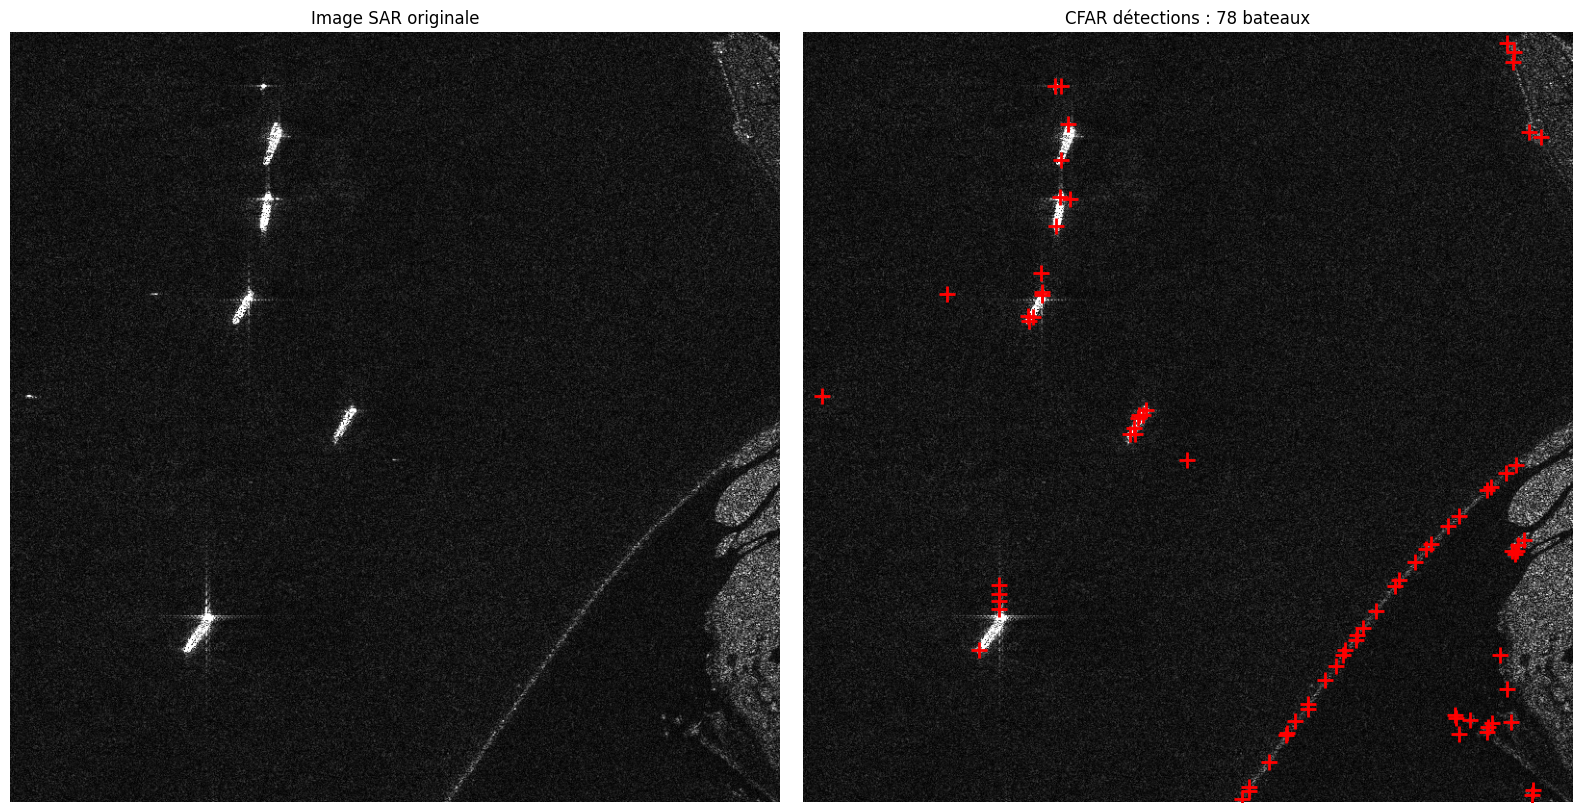

In [38]:
import numpy as np
from scipy import ndimage

# ── 1. Charge une tuile HRSID ─────────────────────────────────────────────────
obj = s3.get_object(Bucket="edth2026-baltic", Key=sample_key)
img = mpimg.imread(BytesIO(obj["Body"].read()))

# Convertit en float niveaux de gris si RGB
if len(img.shape) == 3:
    img_gray = img.mean(axis=2)
else:
    img_gray = img.astype(float)

print(f"Image: {img_gray.shape}, min={img_gray.min():.3f}, max={img_gray.max():.3f}")

# ── 2. CFAR ───────────────────────────────────────────────────────────────────
# Idée : pour chaque pixel, compare sa valeur à la moyenne locale de son voisinage
# Si pixel >> moyenne locale × seuil → c'est un bateau

def cfar_detect(image, guard=4, window=16, threshold=4.0):
    """
    guard   : pixels ignorés autour de la cible (évite l'auto-détection)
    window  : taille de la fenêtre de contexte local
    threshold: facteur multiplicatif au dessus de la moyenne locale → détection
    """
    detections = np.zeros_like(image, dtype=bool)
    pad = window + guard
    
    # Moyenne locale via convolution (rapide)
    kernel_size = 2 * window + 1
    local_mean = ndimage.uniform_filter(image, size=kernel_size)
    
    # Masque la zone guard (évite que le bateau lui-même pollue sa propre moyenne)
    guard_mean = ndimage.uniform_filter(image, size=2 * guard + 1)
    
    # Seuil adaptatif
    threshold_map = local_mean * threshold
    detections = image > threshold_map
    
    return detections

detections = cfar_detect(img_gray, guard=4, window=16, threshold=3.5)

# ── 3. Regroupe les pixels détectés en "objets" ───────────────────────────────
labeled, n_objects = ndimage.label(detections)
print(f"Objets détectés : {n_objects}")

# Centre de chaque objet détecté
centers = ndimage.center_of_mass(img_gray, labeled, range(1, n_objects + 1))
sizes = ndimage.sum(detections, labeled, range(1, n_objects + 1))

# Filtre les trop petits (bruit) et trop grands (land clutter)
valid = [(c, s) for c, s in zip(centers, sizes) if 2 < s < 500]
print(f"Détections valides (filtre bruit) : {len(valid)}")

# ── 4. Visualise ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img_gray, cmap="gray")
axes[0].set_title("Image SAR originale")
axes[0].axis("off")

axes[1].imshow(img_gray, cmap="gray")
for center, size in valid:
    axes[1].plot(center[1], center[0], 'r+', markersize=12, markeredgewidth=2)
axes[1].set_title(f"CFAR détections : {len(valid)} bateaux")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [39]:
# Cherche les fichiers JSON d'annotations dans HRSID
response = s3.list_objects_v2(
    Bucket="edth2026-baltic",
    Prefix="kaggle/high-resolution-sar-images-dataset-hrsid/",
)
for obj in response.get("Contents", []):
    if not obj["Key"].endswith(".png"):
        print(obj["Key"])

kaggle/high-resolution-sar-images-dataset-hrsid/annotations/test2017.json
kaggle/high-resolution-sar-images-dataset-hrsid/annotations/train2017.json
kaggle/high-resolution-sar-images-dataset-hrsid/annotations/train_test2017.json


In [40]:
import json
from pathlib import Path

# ── 1. Télécharge les annotations ─────────────────────────────────────────────
data_dir = Path("../../data/hrsid")
(data_dir / "images").mkdir(parents=True, exist_ok=True)
(data_dir / "labels").mkdir(parents=True, exist_ok=True)

# Récupère les JSON
response = s3.list_objects_v2(
    Bucket="edth2026-baltic",
    Prefix="kaggle/high-resolution-sar-images-dataset-hrsid/",
)
all_keys = [obj["Key"] for obj in response.get("Contents", [])]
json_keys = [k for k in all_keys if k.endswith(".json")]
png_keys  = [k for k in all_keys if k.endswith(".png")]

print(f"JSON : {len(json_keys)}, Images : {len(png_keys)}")

# Charge le premier JSON pour voir la structure
obj = s3.get_object(Bucket="edth2026-baltic", Key=json_keys[0])
coco = json.loads(obj["Body"].read())

print(f"Clés     : {list(coco.keys())}")
print(f"Images   : {len(coco['images'])}")
print(f"Annots   : {len(coco['annotations'])}")
print(f"Catégories : {coco['categories']}")
print(f"\nExemple image : {coco['images'][0]}")
print(f"Exemple annot : {coco['annotations'][0]}")

JSON : 3, Images : 997
Clés     : ['info', 'licenses', 'images', 'type', 'annotations', 'categories']
Images   : 1962
Annots   : 5922
Catégories : [{'supercategory': None, 'id': 1, 'name': 'ship'}]

Exemple image : {'license': 0, 'url': None, 'file_name': 'P0001_0_800_10190_10990.png', 'height': 800, 'width': 800, 'date_captured': None, 'id': 0}
Exemple annot : {'id': 0, 'image_id': 0, 'category_id': 1, 'segmentation': [[254.0, 79.0, 253.0, 80.0, 252.0, 80.0, 251.0, 80.0, 250.0, 80.0, 249.0, 80.0, 248.0, 80.0, 247.0, 80.0, 246.0, 80.0, 245.0, 80.0, 244.0, 80.0, 243.0, 80.0, 242.0, 80.0, 241.0, 80.0, 240.0, 80.0, 239.0, 80.0, 238.0, 80.0, 238.0, 81.0, 237.0, 82.0, 238.0, 82.0, 239.0, 83.0, 240.0, 83.0, 241.0, 83.0, 242.0, 84.0, 243.0, 84.0, 244.0, 84.0, 245.0, 85.0, 246.0, 86.0, 247.0, 86.0, 248.0, 86.0, 249.0, 86.0, 250.0, 86.0, 251.0, 86.0, 252.0, 86.0, 253.0, 86.0, 254.0, 86.0, 255.0, 85.0, 256.0, 85.0, 257.0, 85.0, 258.0, 85.0, 259.0, 85.0, 260.0, 85.0, 261.0, 85.0, 262.0, 85.0, 263

## Fine-tuning YOLOv8n sur HRSID — détection de bateaux SAR

Remplacement de SARfish : on fine-tune YOLOv8n sur le dataset HRSID (SAR haute résolution, 1 classe `ship`) puis on applique le modèle aux scènes Sentinel-1 Eagle S téléchargées sur S3.

In [ ]:
import json, io, os
from pathlib import Path

# ROOT = racine du projet, indépendant du cwd du kernel
ROOT      = Path(__file__).resolve().parents[2] if "__file__" in dir() else Path(os.getcwd())
# Le notebook est dans data/samples/notebooks/ → remonter 3 niveaux
ROOT      = Path(os.getcwd()).resolve()
while ROOT.name != "hackathon-EDTH2026" and ROOT.parent != ROOT:
    ROOT = ROOT.parent

HRSID_PFX = "kaggle/high-resolution-sar-images-dataset-hrsid"
HRSID_DIR = ROOT / "data" / "hrsid_yolo"

for d in ["images/train", "images/val", "labels/train", "labels/val"]:
    (HRSID_DIR / d).mkdir(parents=True, exist_ok=True)

def load_coco(key):
    return json.loads(s3.get_object(Bucket="edth2026-baltic", Key=key)["Body"].read())

def coco_to_yolo(bbox, iw, ih):
    x, y, w, h = bbox
    return (x + w/2)/iw, (y + h/2)/ih, w/iw, h/ih

splits = {"train": "annotations/train2017.json", "val": "annotations/test2017.json"}

for split, ann_key in splits.items():
    coco = load_coco(f"{HRSID_PFX}/{ann_key}")

    annots = {}
    for ann in coco["annotations"]:
        annots.setdefault(ann["image_id"], []).append(ann["bbox"])

    img_dir = HRSID_DIR / "images" / split
    lbl_dir = HRSID_DIR / "labels" / split
    ok = skip = 0

    for meta in coco["images"]:
        fname  = meta["file_name"]
        iw, ih = meta["width"], meta["height"]
        out_img = img_dir / fname
        out_lbl = lbl_dir / (Path(fname).stem + ".txt")

        if not out_img.exists():
            # Les images sont dans le sous-dossier images/ sur S3
            s3_key = f"{HRSID_PFX}/images/{fname}"
            try:
                data = s3.get_object(Bucket="edth2026-baltic", Key=s3_key)["Body"].read()
                out_img.write_bytes(data)
            except s3.exceptions.NoSuchKey:
                skip += 1
                continue

        with open(out_lbl, "w") as f:
            for bbox in annots.get(meta["id"], []):
                xc, yc, w, h = coco_to_yolo(bbox, iw, ih)
                f.write(f"0 {xc:.6f} {yc:.6f} {w:.6f} {h:.6f}\n")
        ok += 1

    print(f"{split:5s}: {ok} images téléchargées, {skip} absentes sur S3")

yaml_path = HRSID_DIR / "hrsid.yaml"
yaml_path.write_text(
    f"path: {HRSID_DIR}\n"
    "train: images/train\n"
    "val:   images/val\n"
    "nc: 1\n"
    "names: [ship]\n"
)
print(f"\nYAML : {yaml_path}")
print(f"Images train : {len(list((HRSID_DIR / 'images/train').glob('*.png')))}")
print(f"Images val   : {len(list((HRSID_DIR / 'images/val').glob('*.png')))}")

In [ ]:
import torch
from ultralytics import YOLO

# Détecte MPS (Apple Silicon) > CUDA > CPU
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {device}")

TRAIN_PROJECT = ROOT / "runs" / "hrsid"
TRAIN_NAME    = "yolov8n_ship"

model = YOLO("yolov8n.pt")   # poids ImageNet pré-entraînés (déjà dans le dossier)

results = model.train(
    data    = str(yaml_path),
    epochs  = 50,
    imgsz   = 800,          # images HRSID sont nativement 800×800
    batch   = 8,
    device  = device,
    project = str(TRAIN_PROJECT),
    name    = TRAIN_NAME,
    exist_ok= True,
    patience= 15,           # early stopping si pas d'amélioration
    verbose = True,
)

best_weights = TRAIN_PROJECT / TRAIN_NAME / "weights" / "best.pt"
print(f"\nMeilleurs poids : {best_weights}")
print(f"mAP50 val       : {results.results_dict.get('metrics/mAP50(B)', 'N/A'):.4f}")

In [ ]:
import numpy as np
import rasterio
from rasterio.transform import xy as rio_xy
from datetime import datetime, timezone
import geopandas as gpd
from shapely.geometry import Point
from ultralytics import YOLO

INCIDENT_DATE = datetime(2024, 12, 25, tzinfo=timezone.utc)
GEOTIFF_DIR   = ROOT / "data" / "sar" / "sentinel1" / "geotiff"

# ── 1. Sélectionne la scène Eagle S la plus proche de l'incident ──────────────
resp   = s3.list_objects_v2(Bucket="edth2026-baltic", Prefix="sar/sentinel1/geotiff/INC-2024-12-25")
scenes = sorted([o["Key"] for o in resp.get("Contents", [])],
                key=lambda k: Path(k).stem.split("_")[1])

def parse_dt(key):
    return datetime.strptime(Path(key).stem.split("_")[1], "%Y-%m-%dT%H%M%S").replace(tzinfo=timezone.utc)

selected_key = min(scenes, key=lambda k: abs((parse_dt(k) - INCIDENT_DATE).total_seconds()))
scene_dt     = parse_dt(selected_key)
print(f"Scène sélectionnée : {Path(selected_key).name}  ({scene_dt.isoformat()})")

# ── 2. Télécharge le GeoTIFF brut + prépare la bande VH 8-bit ────────────────
raw_tif = GEOTIFF_DIR / Path(selected_key).name
if not raw_tif.exists():
    s3.download_file("edth2026-baltic", selected_key, str(raw_tif))

vh8_tif = GEOTIFF_DIR / (raw_tif.stem + "_vh8bit.tif")
if not vh8_tif.exists():
    with rasterio.open(raw_tif) as src:
        vh   = src.read(2).astype(np.float32)
        meta = src.meta.copy()
    vh_db  = 10 * np.log10(np.maximum(vh, 1e-5))
    vh_u8  = np.clip((vh_db + 25) / 25 * 255, 0, 255).astype(np.uint8)
    meta.update(count=1, dtype="uint8")
    with rasterio.open(vh8_tif, "w", **meta) as dst:
        dst.write(vh_u8, 1)

# ── 3. Inférence YOLOv8 ───────────────────────────────────────────────────────
detector = YOLO(str(best_weights))

# YOLO attend une image RGB — on duplique le canal VH en 3 canaux
with rasterio.open(vh8_tif) as src:
    band   = src.read(1)
    transform = src.transform

rgb = np.stack([band, band, band], axis=-1)   # H×W×3 uint8

preds = detector.predict(rgb, imgsz=800, conf=0.3, verbose=False)[0]
boxes = preds.boxes.xyxy.cpu().numpy()       # [[x1,y1,x2,y2], ...]
confs = preds.boxes.conf.cpu().numpy()

print(f"Détections brutes : {len(boxes)}")

# ── 4. Conversion pixels → lat/lon (via la géotransformation rasterio) ────────
def px_to_latlon(col, row):
    # rio_xy(transform, rows, cols) → (xs=lons, ys=lats) pour EPSG:4326
    lon, lat = rio_xy(transform, row, col)
    return float(lat), float(lon)

records = []
for (x1, y1, x2, y2), conf in zip(boxes, confs):
    col_c = (x1 + x2) / 2
    row_c = (y1 + y2) / 2
    lat, lon = px_to_latlon(col_c, row_c)
    records.append({"confidence": round(float(conf), 3), "geometry": Point(lon, lat)})

offshore = gpd.GeoDataFrame(records, crs="EPSG:4326")

# Filtre grossier : on garde uniquement la zone Gulf of Finland autour d'Eagle S
LAT, LON = 60.30, 26.50
offshore = offshore[
    offshore.geometry.y.between(LAT - 0.6, LAT + 0.6) &
    offshore.geometry.x.between(LON - 0.6, LON + 0.6)
].copy()

print(f"Détections dans la zone Eagle S : {len(offshore)}")
offshore.sort_values("confidence", ascending=False).head(10)

## Eagle S — SARfish vessel detection PoC

Pipeline:
1. Pull a Sentinel-1 GeoTIFF (VV+VH float32) from S3 for the 25 Dec 2024 incident area
2. Extract VH band → convert to 8-bit uint8 (SARfish requirement)
3. Run SARfish → GeoJSON with vessel detections + GPS coordinates
4. Load Danish AIS snapshot from S3 for the same area/time window
5. Cross-reference: SAR detection with no AIS match → dark / phantom vessel flag

In [ ]:
import sys, shutil, subprocess, io
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import rasterio
import geopandas as gpd
import pandas as pd

ROOT = Path("../..").resolve()
SARFISH_DIR = ROOT / "scoring" / "sarfish"
GEOTIFF_DIR = ROOT / "data" / "sar" / "sentinel1" / "geotiff"
GEOTIFF_DIR.mkdir(parents=True, exist_ok=True)

# ── 1. List Eagle S GeoTIFF scenes on S3 ─────────────────────────────────────
resp = s3.list_objects_v2(Bucket="edth2026-baltic", Prefix="sar/sentinel1/geotiff/INC-2024-12-25")
scenes = sorted([obj["Key"] for obj in resp.get("Contents", [])], key=lambda k: Path(k).stem.split("_")[1])
print(f"Found {len(scenes)} Eagle S GeoTIFF scene(s) on S3:")
for k in scenes:
    print(f"  {k}")

# ── 2. Download model weights if missing ──────────────────────────────────────
model_bin = SARFISH_DIR / "model.bin"
GDRIVE_FILE_ID = "1f4hJH9YBeTlNkbWUrbCP-C8ELh0eWJtT"

def _download_gdrive(file_id, dest):
    """Download a large Google Drive file, working around quota/cookie walls."""
    import requests, tqdm
    session = requests.Session()
    # Step 1: get the confirm token (needed for files >100 MB)
    url = f"https://drive.google.com/uc?export=download&id={file_id}"
    r = session.get(url, stream=True, timeout=30)
    token = next((v for k, v in r.cookies.items() if k.startswith("download_warning")), None)
    if token:
        url = f"https://drive.google.com/uc?export=download&id={file_id}&confirm={token}"
        r = session.get(url, stream=True, timeout=30)
    # Step 2: stream to disk
    total = int(r.headers.get("content-length", 0))
    with open(dest, "wb") as f, tqdm.tqdm(total=total, unit="B", unit_scale=True, desc=dest.name) as bar:
        for chunk in r.iter_content(chunk_size=32768):
            f.write(chunk)
            bar.update(len(chunk))
    if dest.stat().st_size < 1_000_000:
        dest.unlink()
        raise RuntimeError("Download looks truncated — Google may be blocking; download model.bin manually.")

if not model_bin.exists():
    print("\nDownloading SARfish model weights (~200 MB)…")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown", "tqdm"], check=True)
    import gdown
    try:
        # fuzzy=True parses the sharing URL instead of the bare ID — avoids quota errors
        gdown.download(
            url=f"https://drive.google.com/file/d/{GDRIVE_FILE_ID}/view",
            output=str(model_bin), fuzzy=True, quiet=False,
        )
    except Exception as e:
        print(f"gdown failed ({e}), trying direct requests fallback…")
        _download_gdrive(GDRIVE_FILE_ID, model_bin)
    print(f"model.bin saved ({model_bin.stat().st_size // 1024 // 1024} MB)")
else:
    print(f"model.bin ready: {model_bin}")

In [ ]:
INCIDENT_DATE = datetime(2024, 12, 25, tzinfo=timezone.utc)

def parse_scene_dt(s3_key):
    # Stem: "INC-2024-12-25_2024-12-25T120000_ASCENDING"
    dt_str = Path(s3_key).stem.split("_")[1]   # "2024-12-25T120000"
    return datetime.strptime(dt_str, "%Y-%m-%dT%H%M%S").replace(tzinfo=timezone.utc)

# Pick scene closest in time to the incident
selected_key = min(scenes, key=lambda k: abs((parse_scene_dt(k) - INCIDENT_DATE).total_seconds()))
scene_dt = parse_scene_dt(selected_key)
print(f"Selected : {Path(selected_key).name}")
print(f"Acquired : {scene_dt.isoformat()}")

# Download raw GeoTIFF from S3
raw_tif = GEOTIFF_DIR / Path(selected_key).name
if not raw_tif.exists():
    print("Downloading from S3…")
    s3.download_file("edth2026-baltic", selected_key, str(raw_tif))
print(f"Local    : {raw_tif} ({raw_tif.stat().st_size // 1024} KB)")

# ── Preprocess: VH band (band 2), float32 → dB → 8-bit uint8 ─────────────────
# SARfish expects single-band 8-bit, EPSG:4326 (already our CRS)
vh8_tif = GEOTIFF_DIR / (raw_tif.stem + "_vh8bit.tif")
if not vh8_tif.exists():
    with rasterio.open(raw_tif) as src:
        vh = src.read(2).astype(np.float32)   # VH = band 2
        meta = src.meta.copy()
    # Convert linear backscatter → dB, then stretch [-25, 0] dB → [0, 255]
    vh_db  = 10 * np.log10(np.maximum(vh, 1e-5))
    vh_u8  = np.clip((vh_db + 25) / 25 * 255, 0, 255).astype(np.uint8)
    meta.update(count=1, dtype="uint8")
    with rasterio.open(vh8_tif, "w", **meta) as dst:
        dst.write(vh_u8, 1)
    print(f"Saved 8-bit VH → {vh8_tif}")
else:
    print(f"Cache hit: {vh8_tif}")

In [ ]:
# ── Run SARfish ───────────────────────────────────────────────────────────────
# SARfish.py uses cwd as rootdir; copy tif in, run, retrieve geojson, clean up
DETECTION_THRESHOLD = 0.5
geojson_name = "detections_eagle_s.geojson"
tif_copy = SARFISH_DIR / vh8_tif.name

shutil.copy(vh8_tif, tif_copy)
try:
    result = subprocess.run(
        [sys.executable, "SARfish.py", vh8_tif.name, geojson_name, str(DETECTION_THRESHOLD)],
        cwd=SARFISH_DIR,
        capture_output=True, text=True, timeout=600,
    )
    print(result.stdout[-3000:] if len(result.stdout) > 3000 else result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-1000:])
finally:
    tif_copy.unlink(missing_ok=True)

# Load and inspect detections
detections = gpd.read_file(SARFISH_DIR / geojson_name)
offshore = detections[~detections["onshore_detection"]].copy()
print(f"\nTotal detections : {len(detections)}")
print(f"Offshore vessels : {len(offshore)}")
offshore[["detection_confidence", "geometry"]].sort_values("detection_confidence", ascending=False).head(10)

In [ ]:
# ── Load AIS snapshot from S3 for Eagle S area ────────────────────────────────
# Danish AIS parquet: s3://edth2026-baltic/ais/parquet/source=danish/year=YYYY/month=MM/day=DD/part-0000.parquet
# Pull ±1 day around the incident to cover the full SAR acquisition window

AIS_DAYS = [
    ("2024", "12", "24"),
    ("2024", "12", "25"),
    ("2024", "12", "26"),
]

LAT, LON = 60.30, 26.50   # Eagle S incident centroid
AREA_DEG  = 0.5            # ~55 km box in Gulf of Finland

dfs = []
for year, month, day in AIS_DAYS:
    key = f"ais/parquet/source=danish/year={year}/month={month}/day={day}/part-0000.parquet"
    try:
        obj = s3.get_object(Bucket="edth2026-baltic", Key=key)
        df  = pd.read_parquet(io.BytesIO(obj["Body"].read()))
        dfs.append(df)
        print(f"  {year}-{month}-{day}: {len(df):,} rows")
    except s3.exceptions.NoSuchKey:
        print(f"  {year}-{month}-{day}: not found — run: python scripts/ingest/danish_ais.py date {year}-{month}-{day}")

if not dfs:
    raise RuntimeError("No AIS parquet found for the Eagle S window.")

ais_all = pd.concat(dfs, ignore_index=True)

# Filter to area + 2-hour window around SAR acquisition
ais_all["ts"] = pd.to_datetime(ais_all["Timestamp"], dayfirst=True, utc=True)
ais_area = ais_all[
    ais_all["Latitude"].between(LAT - AREA_DEG, LAT + AREA_DEG) &
    ais_all["Longitude"].between(LON - AREA_DEG, LON + AREA_DEG)
]
t0 = pd.Timestamp(scene_dt)
ais_window = ais_area[ais_area["ts"].between(t0 - pd.Timedelta(hours=2), t0 + pd.Timedelta(hours=2))]

# One position per MMSI = most recent within the window
ais_snap = ais_window.sort_values("ts").groupby("MMSI").last().reset_index()
print(f"\nAIS vessels in area at acquisition time (±2 h): {len(ais_snap)}")
ais_snap[["MMSI", "Name", "Ship type", "Latitude", "Longitude", "ts"]]

In [ ]:
import folium

MATCH_KM = 2.0   # SAR detection within 2 km of an AIS position → matched

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0
    dlat, dlon = np.radians(lat2 - lat1), np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# ── Cross-reference each SAR detection against AIS snapshot ──────────────────
records = []
for _, det in offshore.iterrows():
    det_lat, det_lon = det.geometry.y, det.geometry.x
    best_dist, best_row = float("inf"), None
    for _, v in ais_snap.iterrows():
        d = haversine_km(det_lat, det_lon, float(v["Latitude"]), float(v["Longitude"]))
        if d < best_dist:
            best_dist, best_row = d, v
    matched = best_dist < MATCH_KM
    records.append({
        "det_lat":       det_lat,
        "det_lon":       det_lon,
        "confidence":    round(float(det["detection_confidence"]), 3),
        "dark_vessel":   not matched,
        "matched_mmsi":  int(best_row["MMSI"]) if matched else None,
        "matched_name":  best_row["Name"]       if matched else None,
        "dist_km":       round(best_dist, 2),
    })

df_res = pd.DataFrame(records).sort_values("dark_vessel", ascending=False)
print(f"Offshore detections : {len(df_res)}")
print(f"  matched AIS       : {(~df_res['dark_vessel']).sum()}")
print(f"  DARK / no AIS     : {df_res['dark_vessel'].sum()}")
display(df_res)

# ── Folium map ────────────────────────────────────────────────────────────────
m = folium.Map(location=[LAT, LON], zoom_start=10, tiles="CartoDB dark_matter")

for _, v in ais_snap.iterrows():
    folium.CircleMarker(
        location=[float(v["Latitude"]), float(v["Longitude"])],
        radius=5, color="cyan", fill=True, fill_opacity=0.8,
        tooltip=f"AIS: {v.get('Name','?')} · MMSI {v['MMSI']} · {v.get('Ship type','?')}",
    ).add_to(m)

for _, r in df_res.iterrows():
    color = "red" if r["dark_vessel"] else "lime"
    tip   = f"DARK  conf={r['confidence']}" if r["dark_vessel"] else f"{r['matched_name']} (Δ{r['dist_km']} km, conf={r['confidence']})"
    folium.CircleMarker(
        location=[r["det_lat"], r["det_lon"]],
        radius=7, color=color, fill=True, fill_opacity=0.65,
        tooltip=tip,
    ).add_to(m)

folium.Marker(
    [LAT, LON], tooltip="Eagle S incident (Estlink 2)",
    icon=folium.Icon(color="orange", icon="anchor", prefix="fa"),
).add_to(m)

folium.map.LayerControl().add_to(m)
m

## Test du modèle Alexis — YOLOv8n fine-tuné sur HRSID

Visualisation des détections sur des images HRSID (val set) avec les bounding boxes du modèle
et les annotations ground truth pour vérifier que le modèle détecte bien les bateaux.

In [ ]:
import json
import random
from pathlib import Path

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from ultralytics import YOLO

# ── Poids entraînés par Alexis (RTX 4090, 50 epochs sur HRSID) ───────────────
WEIGHTS = ROOT / "scoring" / "weights" / "yolov8n_hrsid_best.pt"
assert WEIGHTS.exists(), f"Poids non trouvés : {WEIGHTS}\n→ Télécharge depuis S3 : aws s3 cp s3://edth2026-baltic/scoring/weights/yolov8n_hrsid_best.pt scoring/weights/"

model = YOLO(str(WEIGHTS))
print(f"Modèle chargé  : {WEIGHTS.name}  ({WEIGHTS.stat().st_size // 1024} KB)")
print(f"Classe(s)      : {model.names}")

# ── Sélection d'images val avec des bateaux annotés ──────────────────────────
VAL_IMG_DIR = ROOT / "data" / "hrsid_yolo" / "images" / "val"
VAL_LBL_DIR = ROOT / "data" / "hrsid_yolo" / "labels" / "val"

# Garde uniquement les images qui ont au moins 1 annotation (fichier label non vide)
annotated = [
    f for f in sorted(VAL_IMG_DIR.glob("*.png"))
    if (VAL_LBL_DIR / f.with_suffix(".txt").name).exists()
    and (VAL_LBL_DIR / f.with_suffix(".txt").name).stat().st_size > 0
]
print(f"Images val avec bateaux annotés : {len(annotated)}")

# Choisit 6 images en fixant le seed pour la reproductibilité
random.seed(42)
samples = random.sample(annotated, min(6, len(annotated)))

# ── Inférence + visualisation ─────────────────────────────────────────────────
CONF_THRESHOLD = 0.20   # seuil de confiance pour l'affichage

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle(
    f"YOLOv8n HRSID — détections (conf ≥ {CONF_THRESHOLD})   |   "
    "🟥 prédiction   🟩 ground truth",
    fontsize=13, color="white",
)
fig.patch.set_facecolor("#111111")

for ax, img_path in zip(axes.flat, samples):
    img  = np.array(Image.open(img_path).convert("RGB"))
    H, W = img.shape[:2]

    # Inférence
    result = model.predict(img, imgsz=800, conf=CONF_THRESHOLD, verbose=False)[0]
    pred_boxes = result.boxes.xyxy.cpu().numpy()    # [[x1,y1,x2,y2], ...]
    pred_confs = result.boxes.conf.cpu().numpy()

    # Ground truth (format YOLO : xc yc w h normalisé)
    lbl_path = VAL_LBL_DIR / img_path.with_suffix(".txt").name
    gt_boxes = []
    for line in lbl_path.read_text().splitlines():
        _, xc, yc, bw, bh = map(float, line.split())
        x1 = (xc - bw / 2) * W
        y1 = (yc - bh / 2) * H
        x2 = (xc + bw / 2) * W
        y2 = (yc + bh / 2) * H
        gt_boxes.append((x1, y1, x2, y2))

    ax.imshow(img, cmap="gray" if img.ndim == 2 else None)
    ax.set_title(
        f"{img_path.name[:28]}…\n"
        f"{len(pred_boxes)} détectés  /  {len(gt_boxes)} annotés",
        fontsize=8, color="white",
    )
    ax.set_facecolor("#111111")
    ax.axis("off")

    # Ground truth — vert
    for (x1, y1, x2, y2) in gt_boxes:
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor="#00ff88", facecolor="none",
        ))

    # Prédictions — rouge avec score
    for (x1, y1, x2, y2), conf in zip(pred_boxes, pred_confs):
        ax.add_patch(mpatches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=1.5, edgecolor="#ff4444", facecolor="none",
        ))
        ax.text(
            x1, y1 - 3, f"{conf:.2f}",
            fontsize=7, color="#ff4444", fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.1", fc="#111111", alpha=0.6, ec="none"),
        )

plt.tight_layout()
plt.show()

# ── Résumé chiffré ────────────────────────────────────────────────────────────
total_gt   = sum(
    sum(1 for l in (VAL_LBL_DIR / f.with_suffix(".txt").name).read_text().splitlines() if l.strip())
    for f in samples
)
total_pred = sum(
    len(model.predict(np.array(Image.open(f).convert("RGB")), imgsz=800,
                      conf=CONF_THRESHOLD, verbose=False)[0].boxes)
    for f in samples
)
print(f"\nSur les {len(samples)} images affichées :")
print(f"  Ground truth  : {total_gt} bateaux annotés")
print(f"  Prédictions   : {total_pred} détectés  (conf ≥ {CONF_THRESHOLD})")
print(f"  Recall approx : {min(total_pred/total_gt, 1.0):.1%}" if total_gt else "")
